Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [8]:
# cell for imports. All imports must go here.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [3]:
df = pd.read_csv('train.csv')

print("--- Загальна інформація про датафрейм ---")
df.info()

print("\n--- Перші 5 рядків датасету ---")
print(df.head())

--- Загальна інформація про датафрейм ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Перші 5 рядків датасету ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1 

# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

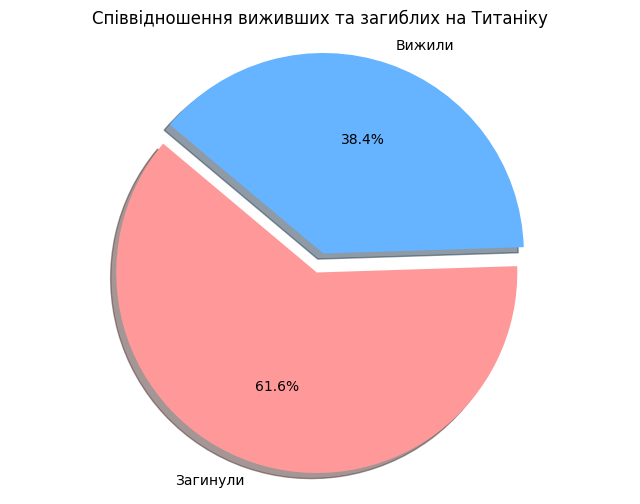

In [5]:
survival_counts = df['Survived'].value_counts()

labels = ['Загинули', 'Вижили']
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)

plt.figure(figsize=(8, 6))
plt.pie(survival_counts, labels=labels, autopct='%1.1f%%',
        startangle=140, colors=colors, explode=explode, shadow=True)

plt.title('Співвідношення виживших та загиблих на Титаніку')
plt.axis('equal')
plt.show()

*прокоментуйте отримані візуалізації Суть візуалізації: Дана діаграма відображає розподіл цільової змінної Survived. Вона дозволяє швидко оцінити загальний рівень смертності під час катастрофи без необхідності вивчати таблиці з числами.

Опис осей та міток:  
Сектори: Кожен колір відповідає певному статусу пасажира.

Відсотки: Показують точну частку кожної групи відносно загальної кількості пасажирів (891 особа у вибірці train).

Висновки:

На графіку чітко видно, що більшість пасажирів (понад 60%) загинули. Це вказує на низький загальний відсоток виживання.

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


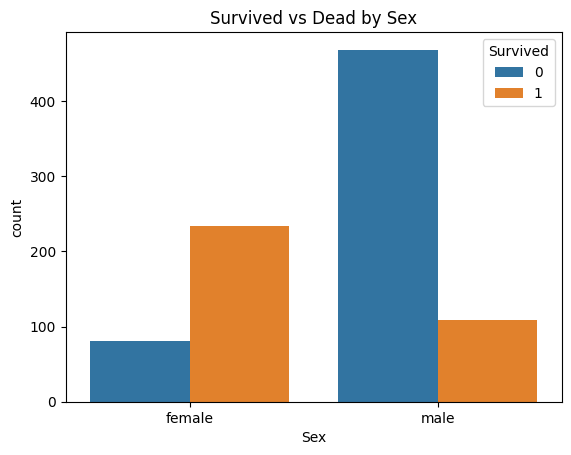

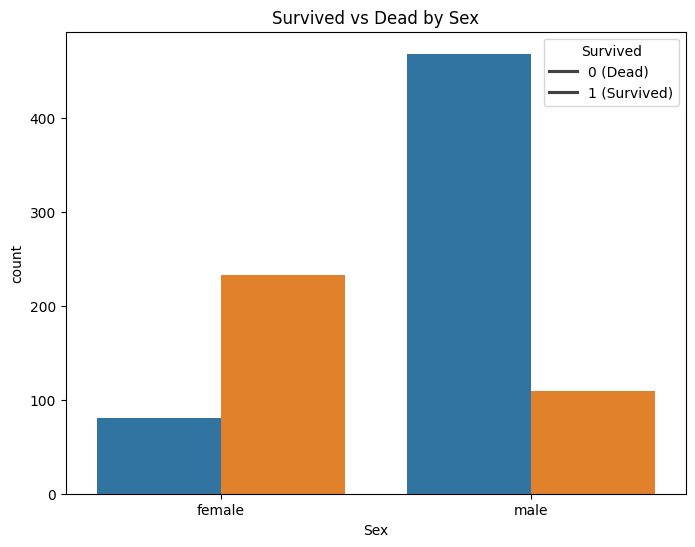

In [9]:
grouped_data = df.groupby(['Sex', 'Survived'], as_index=False).size()
grouped_data.rename(columns={'size': 'count'}, inplace=True)

plt.figure(figsize=(8, 6))
sns.barplot(data=grouped_data, x='Sex', y='count', hue='Survived')

plt.title('Survived vs Dead by Sex')
plt.xlabel('Sex')
plt.ylabel('count')
plt.legend(title='Survived', labels=['0 (Dead)', '1 (Survived)'])

plt.show()

*прокоментуйте отримані візуалізації Суть візуалізації: Цей стовпчиковий графік дозволяє порівняти кількість загиблих (синій колір) та виживших (помаранчевий колір) окремо для чоловіків та жінок.

Опис даних:

Вісь X: Категорії статі (female/male).

Вісь Y: Кількість людей (count).

Легенда: Розподіл за статусом виживання (0 — загинули, 1 — вижили).

Висновки:

На графіку чітко видно величезну різницю у виживанні. Серед жінок кількість тих, хто вижив, значно перевищує кількість загиблих.

Ситуація для чоловіків протилежна — переважна більшість чоловіків на борту загинула.

Це наочно підтверджує дію правила "спочатку жінки та діти" під час евакуації. Стать була одним із вирішальних факторів шансу на порятунок.

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

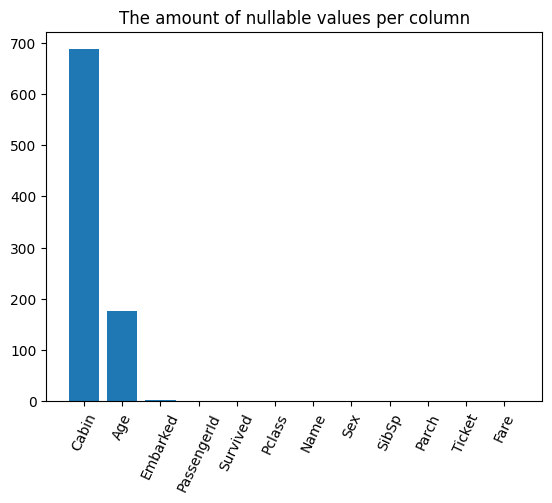

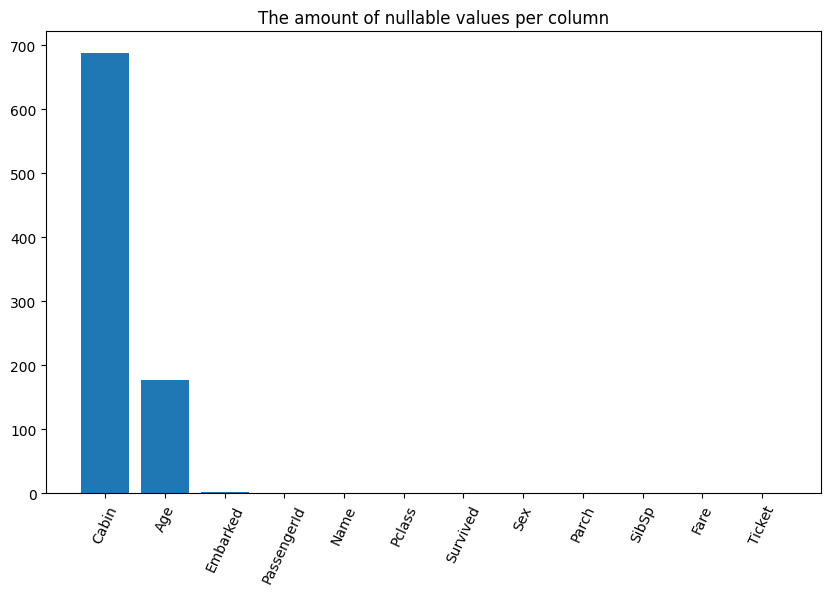

In [10]:
nullable_counts = df.isnull().sum()

nullable_counts = nullable_counts.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(nullable_counts.index, nullable_counts.values)

plt.title('The amount of nullable values per column')
plt.xticks(rotation=65)
plt.show()

*прокоментуйте отримані візуалізації Суть візуалізації: Ми бачимо кількісний розподіл "дірок" у даних (NaN значень). Це допомагає вирішити, які колонки можна спробувати відновити, а які — краще видалити.

Ключові спостереження:

Cabin (Кабіна): Має найбільшу кількість пропусків (близько 700). Це означає, що інформація про номери кабін відсутня для більшості пасажирів, і цю колонку навряд чи можна буде використати для точного аналізу.

Age (Вік): Має значну кількість пропусків (близько 177). Оскільки вік зазвичай є важливим фактором виживання, ці пропуски зазвичай заповнюють медіанним або середнім значенням.

Embarked (Порт посадки): Має лише кілька пропусків, які легко виправити.

Висновок: Графік наочно показує, що датасет потребує очищення перед подальшим використанням у машинному навчанні. Наявність великої кількості пропусків у Cabin робить цю ознаку малоінформативною.

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

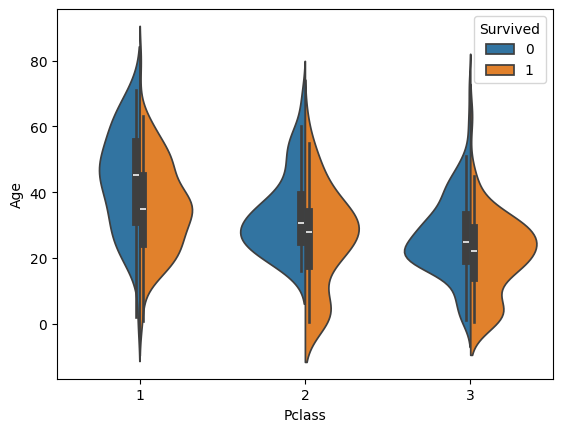

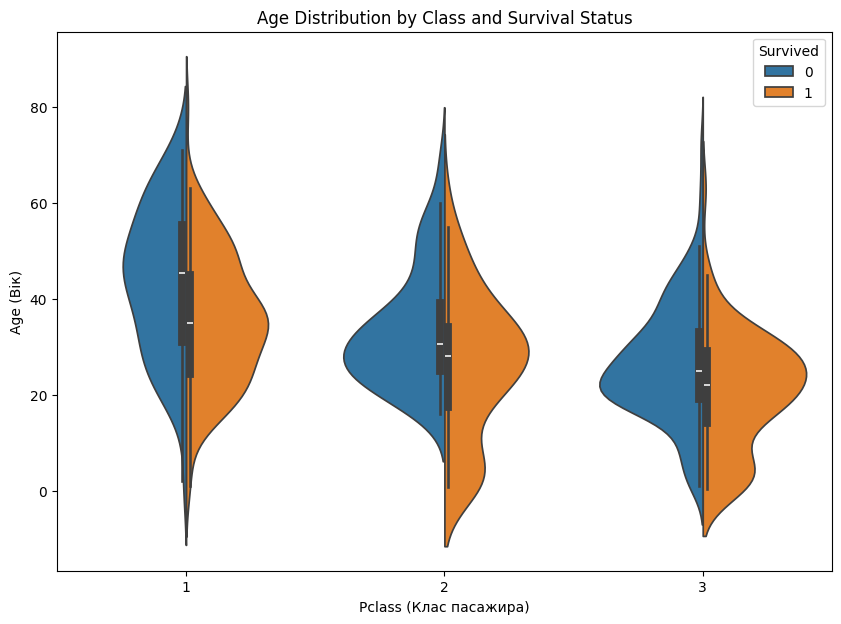

In [11]:
plt.figure(figsize=(10, 7))
sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived', split=True)

plt.title('Age Distribution by Class and Survival Status')
plt.xlabel('Pclass (Клас пасажира)')
plt.ylabel('Age (Вік)')

plt.show()

*прокоментуйте отримані візуалізації Суть візуалізації: Графік відображає розподіл віку пасажирів (Age) залежно від класу кабіни (Pclass) та факту виживання (Survived). Параметр split=True дозволяє порівняти виживших (помаранчевий) та загиблих (синій) всередині одного контуру.

Що ми бачимо на осях:

Вісь X: Три класи пасажирів (1 — найбагатші, 3 — найбідніші).

Вісь Y: Вік пасажирів від 0 до 80+ років.

Ширина: Показує щільність (кількість людей) у цьому віковому діапазоні.

Ключові висновки:

Діти (нижня частина графіків): У 2-му та 3-му класах ми бачимо помітне розширення помаранчевої частини в районі низького віку (близько 0-10 років). Це свідчить про те, що дітей намагалися рятувати першочергово, незалежно від класу.

Статус та вік: Пасажири 1-го класу в середньому старші за пасажирів 3-го класу (центр 1-го класу зміщений вище).

Виживання в 1-му класі: У 1-му класі розподіл виживших (помаранчевий) досить широкий і охоплює майже всі вікові групи, тоді як у 3-му класі він значно вужчий, що вказує на нижчі шанси на порятунок для дорослих у цьому класі.

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


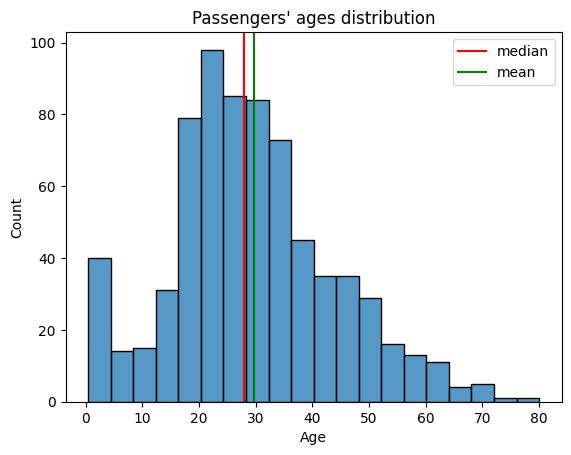

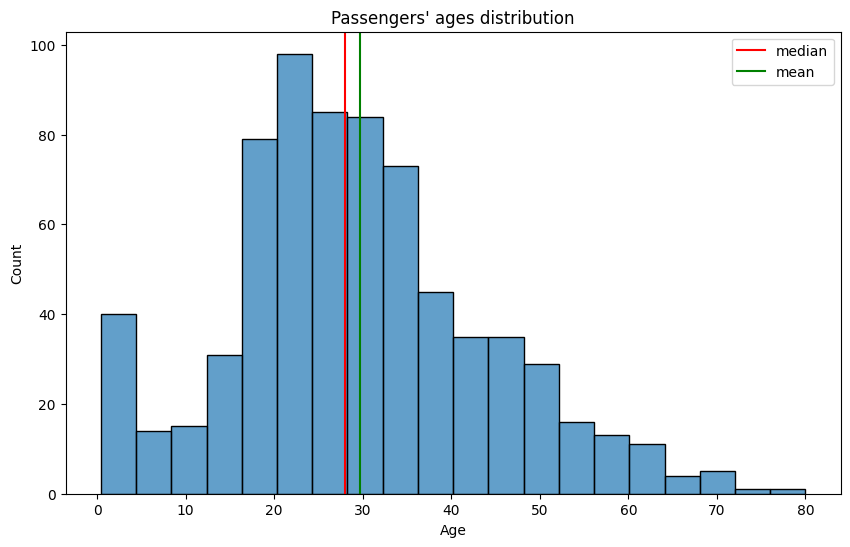

In [12]:
median_age = df['Age'].median()
mean_age = df['Age'].mean()

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'].dropna(), bins=20, edgecolor='black', alpha=0.7)

plt.axvline(median_age, color='red', label=f'median')
plt.axvline(mean_age, color='green', label=f'mean')

plt.title("Passengers' ages distribution")
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()

plt.show()

*прокоментуйте отримані візуалізації Суть візуалізації: Гістограма показує частотний розподіл віку пасажирів Титаніка. Кожен стовпчик відповідає певному віковому діапазону, а його висота — кількості людей у ньому.

Центральні тенденції:

Червона лінія (медіана): Показує значення віку, яке ділить вибірку навпіл. Оскільки вона знаходиться лівіше від середнього, ми бачимо невеликий "перекіс" у бік молодих людей.

Зелена лінія (середнє): Середній вік пасажира, який становить приблизно 29-30 років.

Ключові спостереження:

Молода аудиторія: Найбільша група пасажирів перебуває у віці від 20 до 30
років.

Дитячий пік: Зліва помітний невеликий сплеск (біля 0-5 років) — це велика кількість немовлят та маленьких дітей на борту.

Згасання: Після 40 років кількість пасажирів стрімко зменшується, а людей похилого віку (70+) на кораблі було одиниці.

Висновок: Більшість пасажирів були молодими людьми працездатного віку, що є типовим для тогочасних міграційних та туристичних потоків.

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

*питання до даних Як клас квитка та порт посадки впливали на ціну квитка, і чи є зв'язок між високою вартістю квитка та шансами на виживання?

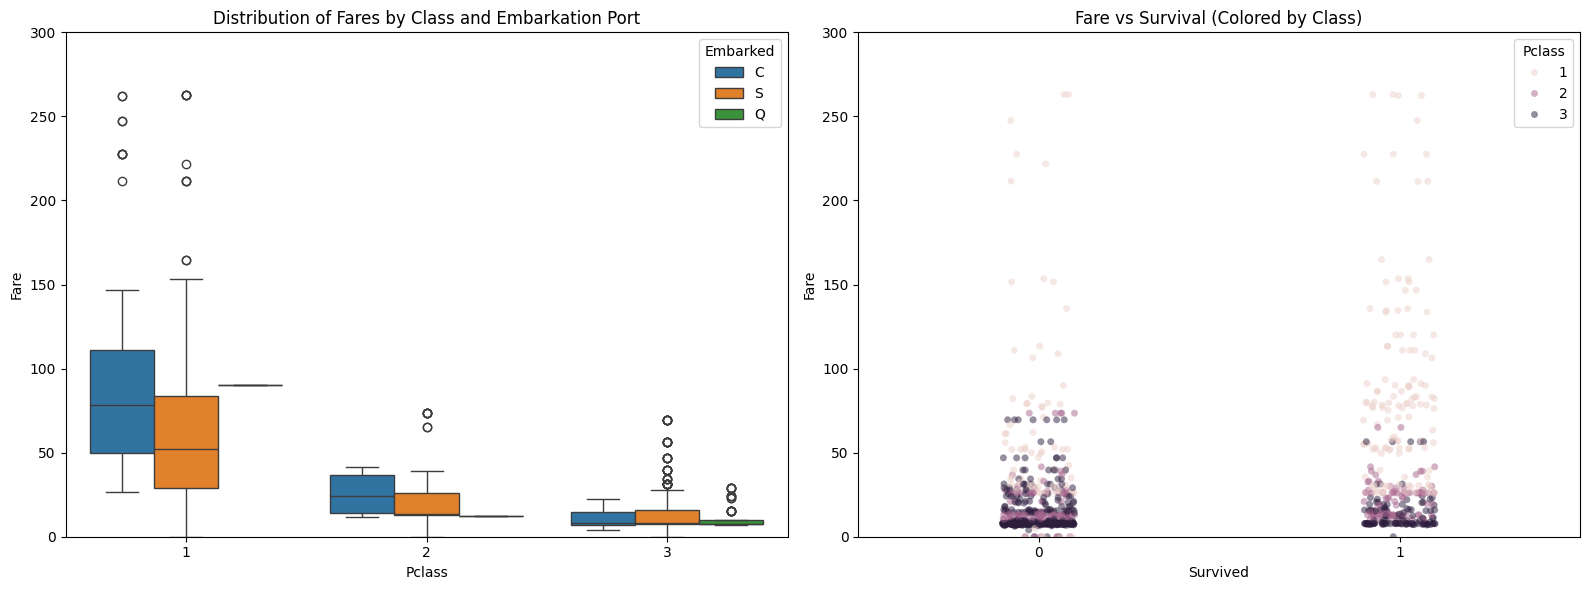

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Pclass', y='Fare', hue='Embarked', ax=ax[0])
ax[0].set_title('Distribution of Fares by Class and Embarkation Port')
ax[0].set_ylim(0, 300)

sns.stripplot(data=df, x='Survived', y='Fare', hue='Pclass', alpha=0.5, ax=ax[1])
ax[1].set_title('Fare vs Survival (Colored by Class)')
ax[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

*прокоментуйте отримані візуалізації Аналіз цін (Лівий графік):
Результат: Як і очікувалося, 1-й клас має значно вищу медіанну ціну та величезний розкид значень.

Спостереження: Пасажири, що сіли в порту C (Cherbourg), в середньому платили більше за квитки 1-го класу. Це може свідчити про те, що в Шербурі на борт піднімалася найбільш заможна публіка.

Викиди: Ми бачимо багато точок вище "вусів" графіка — це супер-дорогі квитки (люкс-каюти), ціна яких значно перевищувала середню.

Зв'язок ціни та виживання (Правий графік):
Результат: Серед тих, хто вижив (Survived = 1), щільність точок у верхній частині графіка (висока ціна) значно більша, ніж серед загиблих.

Спостереження: Більшість пасажирів, які платили за квиток понад 100 фунтів (майже всі вони з 1-го класу), змогли врятуватися. Натомість "хмара" загиблих зосереджена в самому низу (низька ціна, 3-й клас).

Висновок: Вартість квитка була непрямим, але дуже сильним індикатором шансу на виживання. Це пояснюється тим, що каюти 1-го класу були розташовані ближче до палуби з човнами, тоді як пасажири з дешевими квитками знаходилися на нижніх ярусах і мали обмежений доступ до евакуації.

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

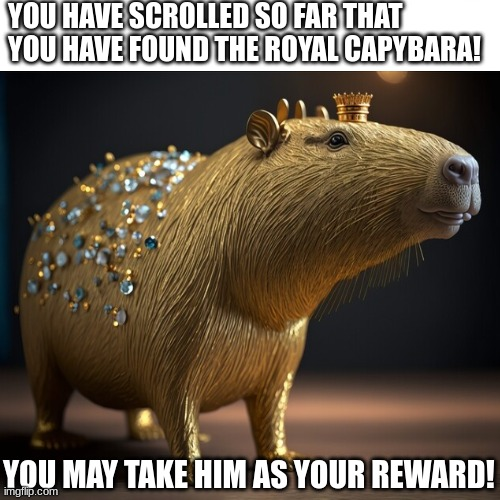